<a href="https://colab.research.google.com/github/rauf358/Similarity-Search-System-using-Deep-Embeddings/blob/main/Similarity_search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# import libraries

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from tqdm  import tqdm


In [ ]:
try:
  import pytorch_metric_learning
except:
  !pip install pytorch-metric-learning

In [ ]:
from pytorch_metric_learning import losses,samplers,miners,testers




# Setup Device Augnostic code

In [ ]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

# get the data

In [ ]:
import requests
import os
if os.path.isdir('data')==False:
    os.mkdir('data')
    print("making data folder")
else:
    print("data folder already exists")




data folder already exists


In [ ]:
if os.path.isdir("casia-face-dataset.zip"):
    print("data already downloaded")
else:
  req=requests.get("https://www.kaggle.com/api/v1/datasets/download/cybersimar08/casia-face-dataset")
  with open("/content/data/casia-face-dataset.zip","wb") as f:
      f.write(req.content)
      print("downloading data")

downloading data


In [ ]:
import zipfile
with zipfile.ZipFile(r"/content/data/casia-face-dataset.zip","r") as zip_ref:
    zip_ref.extractall(r"/content/data")

In [ ]:
from pathlib import Path
file_path = Path("helper_functions.py")
if file_path.is_file():
  print("helper function already downloaded")
else:
  print("downloading helper functions")
  req=requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(req.content)

helper function already downloaded


In [ ]:
from helper_functions import walk_through_dir
walk_through_dir("data")

There are 2 directories and 1 images in 'data'.
There are 200 directories and 0 images in 'data/casia dataset'.
There are 0 directories and 101 images in 'data/casia dataset/000018'.
There are 0 directories and 101 images in 'data/casia dataset/000469'.
There are 0 directories and 101 images in 'data/casia dataset/000305'.
There are 0 directories and 101 images in 'data/casia dataset/000554'.
There are 0 directories and 101 images in 'data/casia dataset/000455'.
There are 0 directories and 101 images in 'data/casia dataset/000319'.
There are 0 directories and 101 images in 'data/casia dataset/000684'.
There are 0 directories and 101 images in 'data/casia dataset/000524'.
There are 0 directories and 101 images in 'data/casia dataset/000467'.
There are 0 directories and 101 images in 'data/casia dataset/000249'.
There are 0 directories and 101 images in 'data/casia dataset/000590'.
There are 0 directories and 101 images in 'data/casia dataset/000081'.
There are 0 directories and 101 imag

In [ ]:
import os

def count_folders(path):
    return sum(os.path.isdir(os.path.join(path, name)) for name in os.listdir(path))

folder_path = "/content/data/casia dataset"
print(f"Number of folders: {count_folders(folder_path)}")


Number of folders: 200


there are 200 folders and 101 images in each **folder**


meanimg and 200 peoples and 101 images for each person


# Plot a random Image

(np.float64(-0.5), np.float64(111.5), np.float64(111.5), np.float64(-0.5))

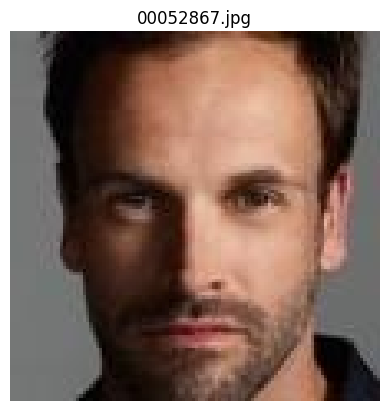

In [ ]:
import matplotlib.pyplot as plt
import random
from pathlib import Path

image_folder_dir = Path("data/casia dataset")
image=random.choice(os.listdir(image_folder_dir))
image_path=image_folder_dir/image
image=random.choice(os.listdir(image_path))
plt.imshow(plt.imread(image_path/image))
plt.title(image)

plt.axis(False)

# structure the data

In [ ]:
import os
import shutil
import random

def split_dataset(input_dir, output_dir, train_ratio=0.8):
    random.seed(42)

    classes = os.listdir(input_dir)
    for cls in classes:
        cls_path = os.path.join(input_dir, cls)
        if not os.path.isdir(cls_path):
            continue

        images = os.listdir(cls_path)
        random.shuffle(images)

        train_count = int(len(images) * train_ratio)
        train_images = images[:train_count]
        test_images = images[train_count:]

        # Create train/test folders
        for split, split_images in zip(['train', 'test'], [train_images, test_images]):
            split_cls_path = os.path.join(output_dir, split, cls)
            os.makedirs(split_cls_path, exist_ok=True)
            for img in split_images:
                src = os.path.join(cls_path, img)
                dst = os.path.join(split_cls_path, img)
                shutil.copy2(src, dst)

input_dir = "data/casia dataset"
output_dir = "data/casia_split"
split_dataset(input_dir, output_dir)


Sure! Let's go line-by-line and explain the full code you've posted. This script splits your image dataset into training and testing folders that are compatible with `ImageFolder` in PyTorch.

---

### 🔶 Imports

```python
import os
import shutil
import random
```

These import necessary libraries:

* `os`: for directory and file path handling.
* `shutil`: to copy image files.
* `random`: to shuffle the list of images randomly.

---

### 🔶 Function Definition

```python
def split_dataset(input_dir, output_dir, train_ratio=0.8):
```

This defines a function named `split_dataset` which:

* Takes an input directory (`input_dir`) — your original dataset (e.g., `"data/casia dataset"`).
* Takes an output directory (`output_dir`) — where the new `train/` and `test/` folders will be created (e.g., `"data/casia_split"`).
* `train_ratio=0.8` means 80% of the data will be for training, 20% for testing.

---

### 🔶 Fix the Randomness for Reproducibility

```python
    random.seed(42)
```

Sets a fixed seed so that every time you run the script, the train-test split will be the same.

---

### 🔶 Get All Subfolders (Classes)

```python
    classes = os.listdir(input_dir)
```

Lists all folders inside `input_dir`.

🔸 **Example**: If `input_dir = "data/casia dataset"` contains:

```
data/casia dataset/
    000001/
    000002/
```

Then:

```python
classes = ['000001', '000002']
```

---

### 🔶 Loop Over Each Class Folder

```python
    for cls in classes:
        cls_path = os.path.join(input_dir, cls)
        if not os.path.isdir(cls_path):
            continue
```

This loop:

* Builds the full path to the class folder (e.g., `data/casia dataset/000001`).
* Skips if it's not a directory (e.g., in case there's a file inside `casia dataset`).

---

### 🔶 List Images and Shuffle Them

```python
        images = os.listdir(cls_path)
        random.shuffle(images)
```

Lists all images inside a class folder, and shuffles them.

🔸 **Example**: If `cls_path = data/casia dataset/000001` contains:

```
00000016.jpg
00000017.jpg
00000018.jpg
00000019.jpg
00000020.jpg
```

Then after shuffling, it may become:

```python
images = ['00000019.jpg', '00000016.jpg', '00000018.jpg', '00000020.jpg', '00000017.jpg']
```

---

### 🔶 Split into Train and Test

```python
        train_count = int(len(images) * train_ratio)
        train_images = images[:train_count]
        test_images = images[train_count:]
```

Calculates how many images should go into training.

🔸 **Example**: If you have 5 images and `train_ratio=0.8`, then:

```python
train_count = int(5 * 0.8) = 4
train_images = first 4 shuffled images
test_images = last 1 image
```

---

### 🔶 Copy Files to New Folders

```python
        for split, split_images in zip(['train', 'test'], [train_images, test_images]):
            split_cls_path = os.path.join(output_dir, split, cls)
            os.makedirs(split_cls_path, exist_ok=True)
```

This:

* Loops twice: once for `train`, once for `test`.
* Builds the folder path for each (e.g., `data/casia_split/train/000001`).
* Creates the directory if it doesn't exist (`exist_ok=True`).

---

### 🔶 Copy Each Image to the Right Folder

```python
            for img in split_images:
                src = os.path.join(cls_path, img)
                dst = os.path.join(split_cls_path, img)
                shutil.copy2(src, dst)
```

This:

* Builds full `src` (source path) and `dst` (destination path) for each image.
* Copies the image using `shutil.copy2()` which also keeps metadata like creation time.

🔸 **Example**:

* `src = data/casia dataset/000001/00000019.jpg`
* `dst = data/casia_split/train/000001/00000019.jpg`

After the copy, your folder structure becomes:

```
data/
└── casia_split/
    ├── train/
    │   └── 000001/
    │       ├── 00000019.jpg
    │       ├── ...
    └── test/
        └── 000001/
            ├── ...
```

---

### 🔶 Calling the Function

```python
input_dir = "data/casia dataset"
output_dir = "data/casia_split"
split_dataset(input_dir, output_dir)
```

This sets the input and output paths and calls the `split_dataset` function.

---

### ✅ Final Output Example Structure

```
data/
└── casia_split/
    ├── train/
    │   ├── 000001/
    │   │   ├── 00000016.jpg
    │   │   └── ...
    │   └── 000002/
    │       └── ...
    └── test/
        ├── 000001/
        │   └── 00000020.jpg
        └── 000002/
            └── ...
```

Now this is compatible with `torchvision.datasets.ImageFolder`.

---

Let me know if you want to turn this into a CLI script, or save the split info in a `.csv` file for reproducibility.


# Load Pretrained Models

In [ ]:
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.models import vit_b_16, ViT_B_16_Weights

resnet_model=resnet50(weights=ResNet50_Weights.DEFAULT).to(device)

vit_model=vit_b_16(weights=ViT_B_16_Weights.DEFAULT).to(device)

resnet_auto_transforms=ResNet50_Weights.DEFAULT.transforms()

vit_auto_transforms=ViT_B_16_Weights.DEFAULT.transforms()

# Create Some Dataloaders Old Implementation

In [ ]:
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision import datasets
train_data_resnet=datasets.ImageFolder("data/casia_split/train",transform=resnet_auto_transforms)
test_data_resnet=datasets.ImageFolder("data/casia_split/test",transform=resnet_auto_transforms)


train_dataloader_resnet=DataLoader(train_data_resnet,batch_size=32,shuffle=True)
test_dataloader_resnet=DataLoader(test_data_resnet,batch_size=32,shuffle=True)
train_dataloader_resnet,test_dataloader_resnet

(<torch.utils.data.dataloader.DataLoader at 0x7be72890a850>,
 <torch.utils.data.dataloader.DataLoader at 0x7be728a5e250>)

# **Create New Dataloader New Implementation**

MperclassSampler Implementation

In [ ]:
train_data_resnet=datasets.ImageFolder("data/casia_split/train",transform=resnet_auto_transforms)
test_data_resnet=datasets.ImageFolder("data/casia_split/test",transform=resnet_auto_transforms)

sampler=samplers.MPerClassSampler(train_data_resnet.targets,m=4)# labels and m is number of sames faces from each indivaual class per batch

train_dataloader_resnet=DataLoader(train_data_resnet,batch_size=32,sampler=sampler,shuffle=False)
test_dataloader_resnet=DataLoader(test_data_resnet,batch_size=32,shuffle=False)
train_dataloader_resnet,test_dataloader_resnet

(<torch.utils.data.dataloader.DataLoader at 0x7be72ff43550>,
 <torch.utils.data.dataloader.DataLoader at 0x7be72ff42f50>)

# lets See whats Inside our Data Loader

In [ ]:
image,label=next(iter(train_dataloader_resnet))
image.shape,label.shape

(torch.Size([32, 3, 224, 224]), torch.Size([32]))

Text(0.5, 1.0, 'tensor(55)')

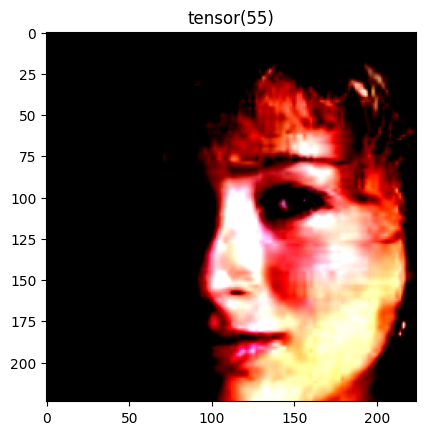

In [ ]:
image,label=next(iter(train_dataloader_resnet))

plt.imshow(image[0].permute(1,2,0))
plt.title(label[0])

# Instanciating torchinfo() Summary

In [ ]:
try:
  from torchinfo import summary
except:
  !pip install torchinfo
  from torchinfo import summary

# Freeze the intermediate layers of Resnet50

for param in resnet_model.parameters():
  param.requires_grad=False

In [ ]:
summary(resnet_model,input_size=(32,3,224,224),
        col_names=["input_size","output_size","num_params","trainable"],
        col_width=20,
        row_settings=["var_names"]
        )

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
ResNet (ResNet)                          [32, 3, 224, 224]    [32, 1000]           --                   True
├─Conv2d (conv1)                         [32, 3, 224, 224]    [32, 64, 112, 112]   9,408                True
├─BatchNorm2d (bn1)                      [32, 64, 112, 112]   [32, 64, 112, 112]   128                  True
├─ReLU (relu)                            [32, 64, 112, 112]   [32, 64, 112, 112]   --                   --
├─MaxPool2d (maxpool)                    [32, 64, 112, 112]   [32, 64, 56, 56]     --                   --
├─Sequential (layer1)                    [32, 64, 56, 56]     [32, 256, 56, 56]    --                   True
│    └─Bottleneck (0)                    [32, 64, 56, 56]     [32, 256, 56, 56]    --                   True
│    │    └─Conv2d (conv1)               [32, 64, 56, 56]     [32, 64, 56, 56]     4,096                True
│    │    └─BatchN

# Edit the Linear layer

In [ ]:
resnet_model.fc=torch.nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(in_features=2048,out_features=512)
)

In [ ]:
summary(resnet_model,input_size=(32,3,224,224),
        col_names=["input_size","output_size","num_params","trainable"],
        col_width=20,
        row_settings=["var_names"]
        )

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
ResNet (ResNet)                          [32, 3, 224, 224]    [32, 512]            --                   True
├─Conv2d (conv1)                         [32, 3, 224, 224]    [32, 64, 112, 112]   9,408                True
├─BatchNorm2d (bn1)                      [32, 64, 112, 112]   [32, 64, 112, 112]   128                  True
├─ReLU (relu)                            [32, 64, 112, 112]   [32, 64, 112, 112]   --                   --
├─MaxPool2d (maxpool)                    [32, 64, 112, 112]   [32, 64, 56, 56]     --                   --
├─Sequential (layer1)                    [32, 64, 56, 56]     [32, 256, 56, 56]    --                   True
│    └─Bottleneck (0)                    [32, 64, 56, 56]     [32, 256, 56, 56]    --                   True
│    │    └─Conv2d (conv1)               [32, 64, 56, 56]     [32, 64, 56, 56]     4,096                True
│    │    └─BatchN

# Loss Function and Optimizer

loss_fn=torch.nn.TripletMarginLoss(margin=0.05)
optimizer=torch.optim.Adam(params=resnet_model.parameters(),lr=0.0001)

# Instanciate Miner

In [ ]:
miner=miners.TripletMarginMiner(margin=1)


https://kevinmusgrave.github.io/pytorch-metric-learning/miners/

# define loss and Optimizer

In [ ]:
loss_fn=losses.TripletMarginLoss(margin=1)
optimizer=torch.optim.Adam(params=resnet_model.parameters(),lr=1e-4,weight_decay=1e-4)
scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="max",factor=0.1, patience=1, verbose=True)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


# Setup Accuracy calculator

In [ ]:
try:
  import faiss
  from pytorch_metric_learning.utils.accuracy_calculator import AccuracyCalculator
  accuracy_calculator = AccuracyCalculator(include=(), k="max_bin_count")
except:
  print("faiss not found, installing faiss-cpu...")
  !pip install faiss-cpu
  import faiss    # or faiss-cpu if you don't have a GPU
  from pytorch_metric_learning.utils.accuracy_calculator import AccuracyCalculator
  accuracy_calculator = AccuracyCalculator(include=("mean_average_precision","precision_at_1","mean_reciprocal_rank"), k="max_bin_count")

# Define Train_step and Test_step

In [ ]:
def train_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    miner:torch.nn.Module):
    model.train()
    train_loss =0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        embeddings=torch.nn.functional.normalize(y_pred, p=2, dim=1)# p= 2 ,indecate l2 norm
        Triplet=miner(embeddings,y)
        loss = loss_fn(embeddings, y,Triplet)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    train_loss /= len(dataloader)
    return train_loss

def test_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    device: torch.device,
    miner:torch.nn.Module,
    accuracy_calculator:AccuracyCalculator):
  model.eval()
  test_loss =0

  all_embeddings = []
  all_labels = []
  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)
      embedding = model(X)
      embeddings=torch.nn.functional.normalize(embedding, p=2, dim=1)# p= 2 ,indecate l2 norm
      Triplet=miner(embeddings,y)
      loss = loss_fn(embeddings, y,Triplet)
      test_loss += loss.item()
      all_embeddings.append(embeddings.cpu())
      all_labels.append(y.cpu())
    all_embeddings = torch.cat(all_embeddings)
    all_labels = torch.cat(all_labels)
  metrics=accuracy_calculator.get_accuracy(
                                    query=all_embeddings,query_labels=all_labels)
  test_loss /= len(dataloader)

  return metrics,test_loss



# define Train function

In [ ]:
def train(
    model: torch.nn.Module,
    train_dataloader: torch.utils.data.DataLoader,
    test_dataloader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: torch.nn.Module,
    epochs: int,
    miner:torch.nn.Module,
    accuracy_calculator:AccuracyCalculator, # Pass the instantiated object
    device: torch.device):
  results = {"train_loss": [], "test_metrics": [],"test_loss":[]} # Store results if you want to plot them later


  for epoch in tqdm(range(epochs)):

    train_loss = train_step(model=model,
                                       dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer,
                                       device=device,
                                       miner=miner)
    metrics,test_loss = test_step(model=model,
                                    dataloader=test_dataloader,
                                    device=device,
                                    accuracy_calculator=accuracy_calculator,
                        miner=miner,
                        loss_fn=loss_fn) # Pass the instantiated object

    metric_for_scheduler = metrics['mean_average_precision'] # Or metrics['precision_at_1']

        # 2. Call scheduler.step()
    scheduler.step(metric_for_scheduler)

        # Get the current learning rate to print (optional, but good for debugging)
    current_lr = optimizer.param_groups[0]['lr']


    print(
            f"Epoch: {epoch+1} | "
            f"LR: {current_lr:.6f} | " # Print current LR
            f"train_loss: {train_loss:.4f} | "
            f"Test Retrieval Metrics (mAP): {metrics['mean_average_precision']:.4f} | "
            f"P@1: {metrics['precision_at_1']:.4f} | " # Simplified print for clarity
            f"Test loss :{test_loss:.4f}"
            # You can print all metrics, but these are key for monitoring
        )

        # Optional: Save results
  results["train_loss"].append(train_loss)
  results["test_metrics"].append(metrics)
  results["test_loss"].append(test_loss)

    # You might want to return the collected results dictionary
  return results

In [ ]:
Resnet50_results=train(model=resnet_model,
                       train_dataloader=train_dataloader_resnet,
                       test_dataloader=test_dataloader_resnet,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       device=device,
                       epochs=3,
                       miner=miner,
                       accuracy_calculator=accuracy_calculator)

100%|██████████| 1/1 [16:34<00:00, 994.26s/it]

Epoch: 1 | train_loss: 0.1726 | Test Retrieval Metrics: {'AMI': np.float64(0.3609314142095246), 'NMI': np.float64(0.6334840842668901), 'mean_average_precision': 0.14251799446218974, 'mean_average_precision_at_r': 0.14250921626222238, 'mean_reciprocal_rank': 0.5152062773704529, 'precision_at_1': 0.41267572075291875, 'r_precision': 0.2221492795605884}


In [ ]:
Resnet50_results=train(model=resnet_model,
                       train_dataloader=train_dataloader_resnet,
                       test_dataloader=test_dataloader_resnet,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       device=device,
                       epochs=3,
                       miner=miner,
                       accuracy_calculator=accuracy_calculator)

 33%|███▎      | 1/3 [16:35<33:11, 995.50s/it]

Epoch: 1 | train_loss: 0.1389 | Test Retrieval Metrics: {'AMI': np.float64(0.4256888685962408), 'NMI': np.float64(0.6720008280324196), 'mean_average_precision': 0.19579817075330855, 'mean_average_precision_at_r': 0.195771209139123, 'mean_reciprocal_rank': 0.5799278020858765, 'precision_at_1': 0.4777221825113176, 'r_precision': 0.2809431548850683}


 67%|██████▋   | 2/3 [33:13<16:36, 996.83s/it]

Epoch: 2 | train_loss: 0.1204 | Test Retrieval Metrics: {'AMI': np.float64(0.4581859789330935), 'NMI': np.float64(0.6905913463711785), 'mean_average_precision': 0.22726278792164284, 'mean_average_precision_at_r': 0.2272477395788416, 'mean_reciprocal_rank': 0.6071665287017822, 'precision_at_1': 0.5218012866333095, 'r_precision': 0.30903652985215}


100%|██████████| 3/3 [49:54<00:00, 998.29s/it]

Epoch: 3 | train_loss: 0.1064 | Test Retrieval Metrics: {'AMI': np.float64(0.48680517413096364), 'NMI': np.float64(0.7065943200076438), 'mean_average_precision': 0.2529870421887448, 'mean_average_precision_at_r': 0.2529444052174746, 'mean_reciprocal_rank': 0.6397032737731934, 'precision_at_1': 0.5556349773647844, 'r_precision': 0.3389632945838506}


In [ ]:
Resnet50_results=train(model=resnet_model,
                       train_dataloader=train_dataloader_resnet,
                       test_dataloader=test_dataloader_resnet,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       device=device,
                       epochs=2,
                       miner=miner,
                       accuracy_calculator=accuracy_calculator)

  0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
def save_model(model: torch.nn.Module,
                target_dir: str,
                model_name: str):
  """Saves a PyTorch model to a target directory."""
  import os
  from pathlib import Path
  if os.path.isdir("models"):
    pass
  else:
    os.mkdir("models")
  # Create target directory
  target_dir_path = Path(target_dir)
  target_dir_path.mkdir(parents=True,
                        exist_ok=True)
  # Create model save path
  MODEL_PATH=Path(target_dir)
  MODEL_PATH.mkdir(parents=True,exist_ok=True)
  model_path=MODEL_PATH/model_name
  torch.save(obj=model.state_dict(),f=model_path)

In [ ]:
Resnet50_results

{'train_loss': [0.10637076945587992],
 'test_metrics': [{'AMI': np.float64(0.48680517413096364),
   'NMI': np.float64(0.7065943200076438),
   'mean_average_precision': 0.2529870421887448,
   'mean_average_precision_at_r': 0.2529444052174746,
   'mean_reciprocal_rank': 0.6397032737731934,
   'precision_at_1': 0.5556349773647844,
   'r_precision': 0.3389632945838506}],
 'test_loss': [0.19954622994092377]}

In [ ]:
save_model(model=resnet_model,target_dir="models",model_name="Resnet50.pth")

In [ ]:
def download_file(file_path):
    from google.colab import files
    files.download(file_path)



In [ ]:
download_file("/content/models/Resnet50.pth")

# Load the model

In [ ]:
resnet_model.load_state_dict(torch.load(r"/content/Resnet50_4.pth", map_location=device))
resnet_model= resnet_model.to(device)

# continue traineing

In [ ]:
summary(resnet_model)

Layer (type:depth-idx)                   Param #
ResNet                                   --
├─Conv2d: 1-1                            9,408
├─BatchNorm2d: 1-2                       128
├─ReLU: 1-3                              --
├─MaxPool2d: 1-4                         --
├─Sequential: 1-5                        --
│    └─Bottleneck: 2-1                   --
│    │    └─Conv2d: 3-1                  4,096
│    │    └─BatchNorm2d: 3-2             128
│    │    └─Conv2d: 3-3                  36,864
│    │    └─BatchNorm2d: 3-4             128
│    │    └─Conv2d: 3-5                  16,384
│    │    └─BatchNorm2d: 3-6             512
│    │    └─ReLU: 3-7                    --
│    │    └─Sequential: 3-8              16,896
│    └─Bottleneck: 2-2                   --
│    │    └─Conv2d: 3-9                  16,384
│    │    └─BatchNorm2d: 3-10            128
│    │    └─Conv2d: 3-11                 36,864
│    │    └─BatchNorm2d: 3-12            128
│    │    └─Conv2d: 3-13               

In [ ]:
resnet_model=resnet_model.to(device)
Resnet50_results=train(model=resnet_model,
                       train_dataloader=train_dataloader_resnet,
                       test_dataloader=test_dataloader_resnet,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       device=device,
                       epochs=3,
                       miner=miner,
                       accuracy_calculator=accuracy_calculator)

 33%|███▎      | 1/3 [16:11<32:22, 971.39s/it]

Epoch: 1 | LR: 0.000100 | train_loss: 0.1158 | Test Retrieval Metrics (mAP): 0.4954 | P@1: 0.7598 | Test loss :0.2147


 67%|██████▋   | 2/3 [32:24<16:12, 972.59s/it]

Epoch: 2 | LR: 0.000100 | train_loss: 0.1041 | Test Retrieval Metrics (mAP): 0.4834 | P@1: 0.7482 | Test loss :0.2351


100%|██████████| 3/3 [48:38<00:00, 972.78s/it]

Epoch: 3 | LR: 0.000100 | train_loss: 0.0992 | Test Retrieval Metrics (mAP): 0.4739 | P@1: 0.7427 | Test loss :0.2350


In [ ]:
Resnet50_results

{'train_loss': [0.09920706847891211],
 'test_metrics': [{'AMI': np.float64(0.6776766773083037),
   'NMI': np.float64(0.8147125165811326),
   'mean_average_precision': 0.4739253687355726,
   'mean_average_precision_at_r': 0.4738407218073156,
   'mean_reciprocal_rank': 0.7913332581520081,
   'precision_at_1': 0.7426733380986419,
   'r_precision': 0.5390328931693064}],
 'test_loss': [0.23498246975412423]}

In [ ]:
resnet_model=resnet_model.to(device)
Resnet50_results=train(model=resnet_model,
                       train_dataloader=train_dataloader_resnet,
                       test_dataloader=test_dataloader_resnet,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       device=device,
                       epochs=3,
                       miner=miner,
                       accuracy_calculator=accuracy_calculator)

 33%|███▎      | 1/3 [16:13<32:27, 973.81s/it]

Epoch: 1 | LR: 0.000100 | train_loss: 0.1848 | Test Retrieval Metrics (mAP): 0.7702 | P@1: 0.9218 | Test loss :0.2517


 67%|██████▋   | 2/3 [32:28<16:14, 974.27s/it]

Epoch: 2 | LR: 0.000100 | train_loss: 0.1559 | Test Retrieval Metrics (mAP): 0.7020 | P@1: 0.8973 | Test loss :0.2743


100%|██████████| 3/3 [48:41<00:00, 973.85s/it]

Epoch: 3 | LR: 0.000100 | train_loss: 0.1582 | Test Retrieval Metrics (mAP): 0.6457 | P@1: 0.8663 | Test loss :0.3245


In [ ]:
model_results


{'train_loss': [0.15824755465477705],
 'test_metrics': [{'AMI': np.float64(0.8068152255985965),
   'NMI': np.float64(0.8857552236023128),
   'mean_average_precision': 0.6456854745728461,
   'mean_average_precision_at_r': 0.6456165030016737,
   'mean_reciprocal_rank': 0.894871711730957,
   'precision_at_1': 0.8663330950679057,
   'r_precision': 0.6923247181570796}],
 'test_loss': [0.3244551267108005]}

In [ ]:
Resnet50_results=train(model=resnet_model,
                       train_dataloader=train_dataloader_resnet,
                       test_dataloader=test_dataloader_resnet,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       device=device,
                       epochs=1,
                       miner=miner,
                       accuracy_calculator=accuracy_calculator)

100%|██████████| 1/1 [16:12<00:00, 972.98s/it]

Epoch: 1 | LR: 0.000050 | train_loss: 0.1640 | Test Retrieval Metrics (mAP): 0.5980 | P@1: 0.8365 | Test loss :0.3773


In [ ]:
net50_results=train(model=resnet_model,
                       train_dataloader=train_dataloader_resnet,
                       test_dataloader=test_dataloader_resnet,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       device=device,
                       epochs=1,
                       miner=miner,
                       accuracy_calculator=accuracy_calculator)

100%|██████████| 1/1 [16:43<00:00, 1003.48s/it]

Epoch: 1 | LR: 0.000100 | train_loss: 0.1851 | Test Retrieval Metrics (mAP): 0.7800 | P@1: 0.9292 | Test loss :0.2439


In [ ]:
save_model(model=resnet_model,target_dir="models",model_name="Resnet50_4.pth")

In [ ]:
download_file("/content/models/Resnet50_4.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
net50_results

{'train_loss': [0.18511559346556664],
 'test_metrics': [{'AMI': np.float64(0.8701469490035513),
   'NMI': np.float64(0.923789368327176),
   'mean_average_precision': 0.77997794215905,
   'mean_average_precision_at_r': 0.779893295230793,
   'mean_reciprocal_rank': 0.9439901113510132,
   'precision_at_1': 0.9292351679771265,
   'r_precision': 0.806325947105075}],
 'test_loss': [0.24387570759845953]}

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


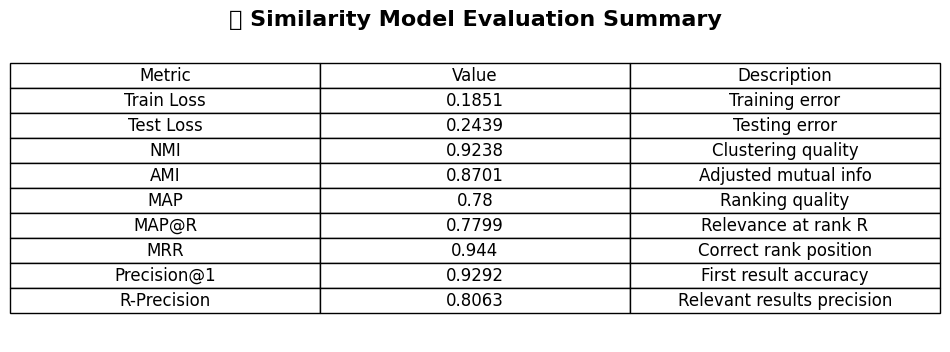

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Define your metrics
metrics = {
    "Metric": [
        "Train Loss", "Test Loss", "NMI", "AMI",
        "MAP", "MAP@R", "MRR", "Precision@1", "R-Precision"
    ],
    "Value": [
        0.1851, 0.2439, 0.9238, 0.8701,
        0.7800, 0.7799, 0.9440, 0.9292, 0.8063
    ],
    "Description": [
        "Training error", "Testing error",
        "Clustering quality", "Adjusted mutual info",
        "Ranking quality", "Relevance at rank R",
        "Correct rank position", "First result accuracy",
        "Relevant results precision"
    ]
}

# Create DataFrame
df = pd.DataFrame(metrics)

# Plot as a styled table
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')  # Turn off axis

# Create table
table = ax.table(cellText=df.values,
                 colLabels=df.columns,
                 cellLoc='center',
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)

plt.title("🔍 Similarity Model Evaluation Summary", fontsize=16, weight='bold')
plt.show()


In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from IPython.display import display, Markdown
import numpy as np

def print_summary_card():
    print("┌" + "─" * 46 + "┐")
    print("│ 🔎 Inference Pipeline: PyTorch Metric Learning │")
    print("├" + "─" * 46 + "┤")
    print("│ ✅ Trunk       : ResNet50                    │")
    print("│ ✅ Embedder    : FC(2048 ➝ 512)              │")
    print("│ 🎯 Normalized  : True                        │")
    print("│ 🔍 MatchFinder : Faiss (Flat)                │")
    print("└" + "─" * 46 + "┘")

def plot_embeddings(embeddings, labels, title="t-SNE of Embeddings"):
    tsne = TSNE(n_components=2, perplexity=30, n_iter=300)
    reduced = tsne.fit_transform(embeddings)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap='tab10', s=15, alpha=0.7)
    plt.colorbar(scatter)
    plt.title(f"🎨 {title}")
    plt.grid(True)
    plt.show()

def show_knn_results(query_img, neighbor_imgs, distances):
    k = len(neighbor_imgs)
    plt.figure(figsize=(15, 4))

    # Show query
    plt.subplot(1, k+1, 1)
    plt.imshow(query_img)
    plt.title("🔍 Query")
    plt.axis('off')

    # Show neighbors
    for i in range(k):
        plt.subplot(1, k+1, i+2)
        plt.imshow(neighbor_imgs[i])
        plt.title(f"Top {i+1}\nDist: {distances[i]:.2f}")
        plt.axis('off')

    plt.suptitle("📥 Nearest Neighbors from InferenceModel", fontsize=16)
    plt.tight_layout()
    plt.show()

def show_markdown_intro():
    display(Markdown("""
# 🔍 **Similarity Inference Pipeline — Final Showcase**
- 🎯 Powered by `InferenceModel` from PyTorch Metric Learning
- 🧠 Backbone: `ResNet50`
- 📏 Embedding Dim: 512
- 🔍 Retrieval Engine: Faiss Flat Index
- 🎨 Visualized using t-SNE and k-NN plots
"""))


# Inference

In [ ]:
from pytorch_metric_learning.utils.inference import InferenceModel
from pytorch_metric_learning.utils.inference import FaissKNN

# Initialize FaissKNN for fast nearest neighbor search
match_finder = FaissKNN(index_init_fn="Flat")  # use your actual embedding size

# Define the inference model
inference_model = InferenceModel(
    trunk=resnet_model,               # Your ResNet or similar
    match_finder=match_finder,       # k-NN search handler
    normalize_embeddings=True,       # Always normalize for cosine-based search
    data_device='cuda' if torch.cuda.is_available() else 'cpu',
    dtype=torch.float32
)


In [ ]:
# Get embeddings and labels for the test set manually
test_embeddings = []
test_labels = []
inference_model.trunk.eval() # Ensure the model is in evaluation mode
with torch.no_grad():
    for images, labels in test_dataloader_resnet:
        images = images.to(device)
        embeddings = inference_model.trunk(images)
        if inference_model.embedder: # Apply embedder if it exists
            embeddings = inference_model.embedder(embeddings)
        if inference_model.normalize_embeddings: # Normalize embeddings if required
            embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)
        test_embeddings.append(embeddings.cpu())
        test_labels.append(labels.cpu())

test_embeddings = torch.cat(test_embeddings)
test_labels = torch.cat(test_labels)

# Initialize the Faiss index with the correct embedding dimensio
# inference_model.match_finder.index_embeddings(test_embeddings, test_labels)

AttributeError: 'FaissKNN' object has no attribute 'index_embeddings'

In [ ]:
# Perform t-SNE dimensionality reduction
tsne = TSNE(n_components=2, perplexity=30, n_iter=300, random_state=42)
tsne_embeddings = tsne.fit_transform(test_embeddings.numpy())
tsne_embeddings = torch.from_numpy(tsne_embeddings) # Convert back to torch tensor if needed later

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


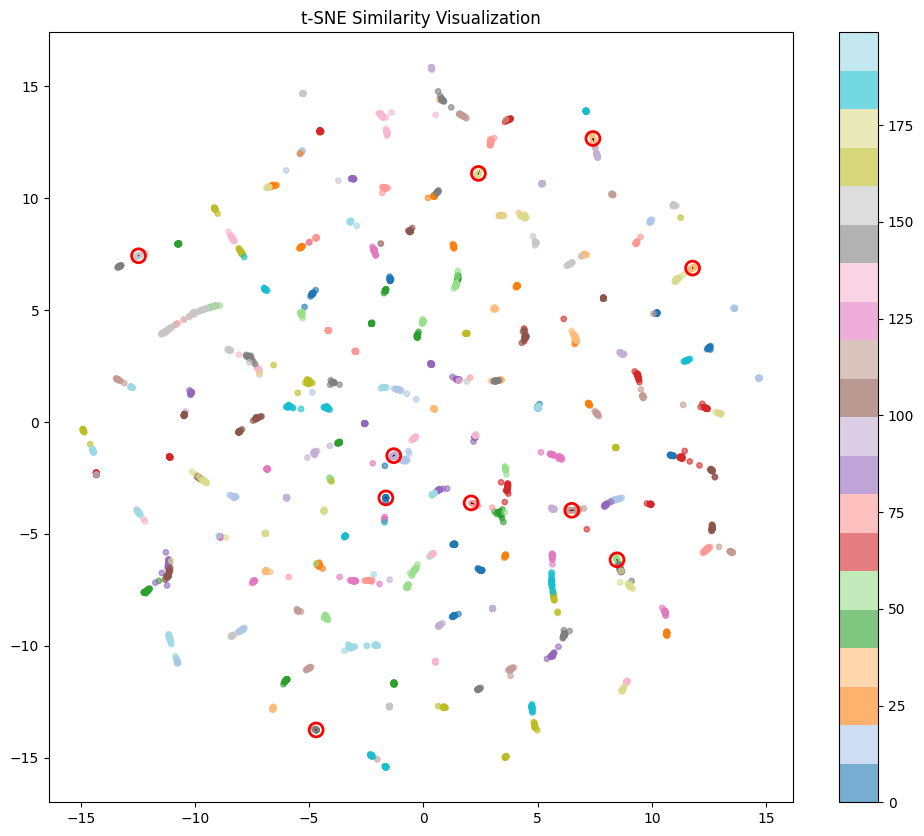

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

# Reduce to CPU numpy for easy handling
embeddings_np = test_embeddings.numpy()
labels_np = test_labels.numpy()
tsne_np = tsne_embeddings # Use the variable created in the previous cell

# Choose a few random query indices
np.random.seed(42)
num_queries = 10
query_indices = np.random.choice(len(embeddings_np), num_queries, replace=False)

# Calculate cosine similarity
similarities = cosine_similarity(embeddings_np)

# Plot the t-SNE points
plt.figure(figsize=(12, 10))
scatter = plt.scatter(tsne_np[:, 0], tsne_np[:, 1], c=labels_np, cmap='tab20', s=15, alpha=0.6)
plt.title("t-SNE Similarity Visualization")
plt.colorbar(scatter)

# Draw similarity lines
for query_idx in query_indices:
    # Get top-5 nearest neighbors (excluding self)
    sims = similarities[query_idx]
    top_k_idx = sims.argsort()[::-1][1:6]  # skip self-match

    for neighbor_idx in top_k_idx:
        plt.plot([tsne_np[query_idx, 0], tsne_np[neighbor_idx, 0]],
                 [tsne_np[query_idx, 1], tsne_np[neighbor_idx, 1]],
                 color='black', linewidth=0.5, alpha=0.6)

    # Highlight the query point
    plt.scatter(tsne_np[query_idx, 0], tsne_np[query_idx, 1],
                edgecolor='red', facecolor='none', s=100, linewidth=2)

plt.show()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

def plot_similarity_grid(images, embeddings, k=5, num_queries=5):
    if isinstance(images, torch.Tensor):
        images = images.permute(0, 2, 3, 1).cpu().numpy()  # [N, C, H, W] → [N, H, W, C]

    embeddings = embeddings.cpu().numpy() if isinstance(embeddings, torch.Tensor) else embeddings

    sim_matrix = cosine_similarity(embeddings)
    query_indices = np.random.choice(len(images), num_queries, replace=False)

    fig, axes = plt.subplots(num_queries, k+1, figsize=(2*(k+1), 2*num_queries))

    for row_idx, q_idx in enumerate(query_indices):
        sims = sim_matrix[q_idx]
        top_k_idx = sims.argsort()[::-1][1:k+1]  # skip self

        indices = [q_idx] + list(top_k_idx)
        for col_idx, img_idx in enumerate(indices):
            axes[row_idx, col_idx].imshow(images[img_idx])
            axes[row_idx, col_idx].axis('off')
            if col_idx == 0:
                axes[row_idx, col_idx].set_title("Query", fontsize=9)
            else:
                axes[row_idx, col_idx].set_title(f"Top-{col_idx}", fontsize=9)

    plt.tight_layout()
    plt.show()


In [ ]:
# Collect a few hundred test images and their embeddings
test_images = []
test_labels = []

# Set a max number of images to extract
max_images = 300

for images, labels in test_dataloader_resnet:
    test_images.extend(images)         # [C, H, W] tensors
    test_labels.extend(labels)

    if len(test_images) >= max_images:
        break

# Truncate to exact number
test_images = test_images[:max_images]
test_labels = test_labels[:max_images]

# Stack into a single tensor
test_images = torch.stack(test_images)     # shape: [N, C, H, W]
test_labels = torch.tensor(test_labels)    # shape: [N]


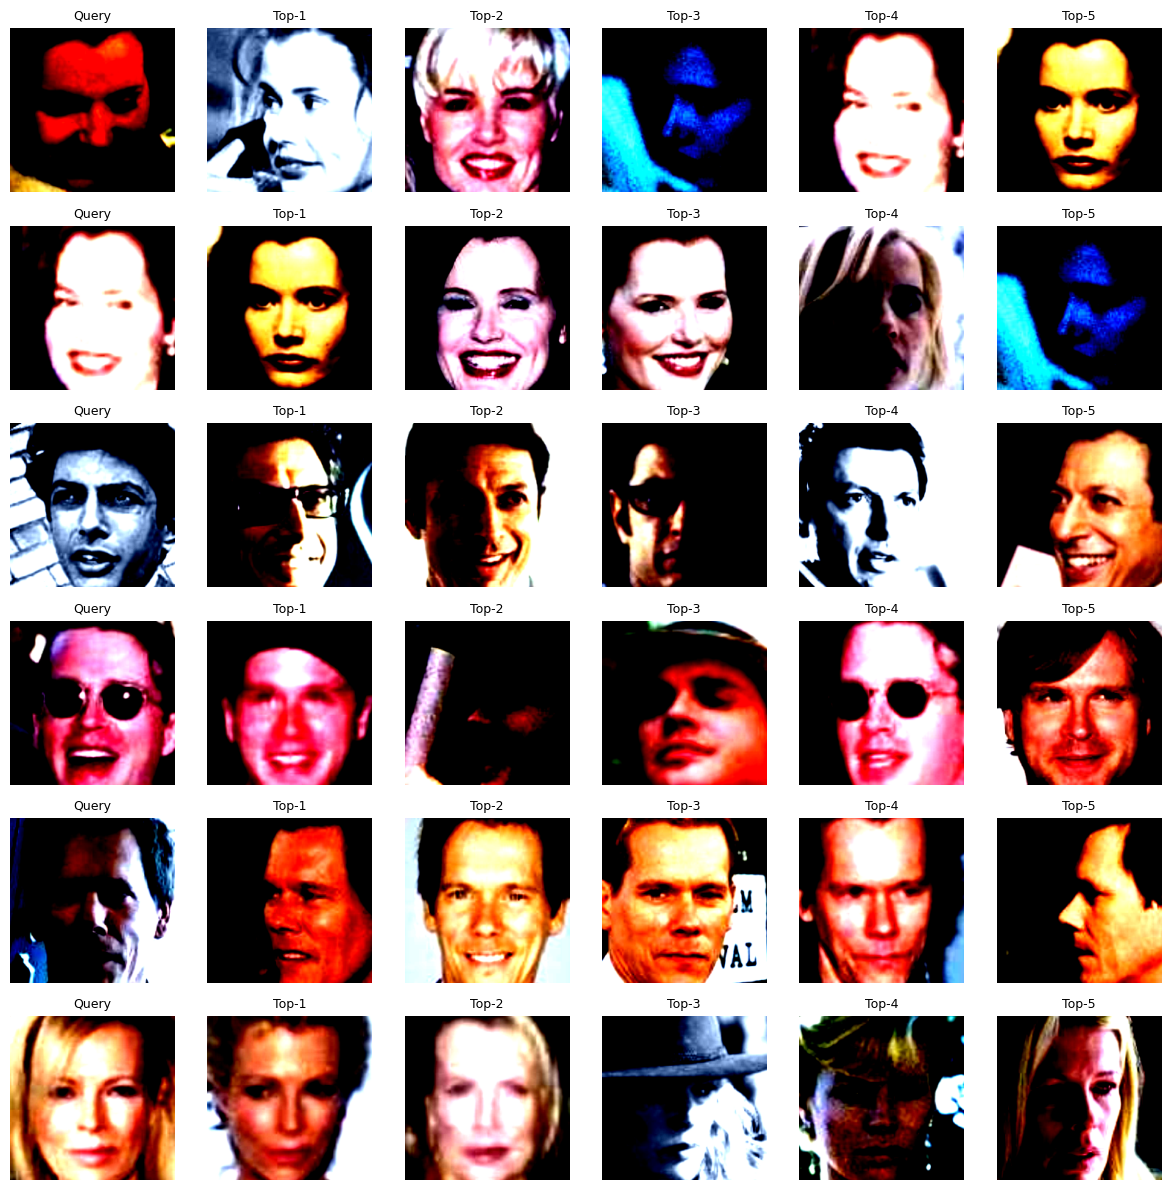

In [ ]:
plot_similarity_grid(test_images, test_embeddings, k=5, num_queries=6)
